In [1]:
import os
import re
import glob
import numpy as np
import pandas as pd
import astropy.units as u
import matplotlib.pyplot as plt

from pathlib import Path
from astropy.io import fits
from astropy.wcs import WCS
from astroquery.simbad import Simbad
from matplotlib.patches import Rectangle
from astroquery.hips2fits import hips2fits
from astropy.coordinates import SkyCoord, Angle

font = {'family' : 'gill sans',
         'size'   : 12,
         'serif':  'cmr10'
         }

plt.rc('font', **font)
plt.rc('axes', unicode_minus = False)

In [2]:
hdul = fits.open('/Users/billyli/Documents/float-for-morrow/LMC/30 Doradus/RMC 140/E140M_1425_0.2x0.2_2670.000_16272/oec159010_x1d.fits')
hdul.info()
R = float(hdul[0].header["SPECRES"])
print(R)

Filename: /Users/billyli/Documents/float-for-morrow/LMC/30 Doradus/RMC 140/E140M_1425_0.2x0.2_2670.000_16272/oec159010_x1d.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     298   ()      
  1  SCI           1 BinTableHDU    158   44R x 19C   [1I, 1I, 1024D, 1024E, 1024E, 1024E, 1024E, 1024E, 1024E, 1024I, 1E, 1E, 1I, 1E, 1E, 1E, 1E, 1024E, 1E]   
45800.0


In [3]:
main_directory = Path().resolve()

In [4]:
def snr_from_spectra(path, Cenwave, Instrument):

    if Cenwave == 1096:

        wave = 1100

    elif Cenwave == 1291 or Cenwave == 1327:

        wave = 1292

    elif Cenwave == 1611 or Cenwave == 1577 or Cenwave == 1623:

        wave = 1630

    elif Cenwave == 1425:

        wave = 1420

    elif Cenwave == 1978:

        wave = 2002

    elif Cenwave == 2707:

        wave = 2800
    
    with fits.open(path) as hdul:
        data = hdul[1].data

        wl = data["WAVELENGTH"]
        flux = data["FLUX"]
        err = data["ERROR"]

        header = hdul[0].header
        R = float(header["SPECRES"])
        dl_pix = float(np.nanmedian(np.diff(wl)))
        dl_res = np.nanmedian(wl) / R

        npix = dl_res / dl_pix
        
        mask = (np.abs(wl - wave) < 0.5) & np.isfinite(flux) & np.isfinite(err) & (err > 0)
        snr = flux[mask] / err[mask] * np.sqrt(npix)

        return float(np.median(snr))

def query_simbad(target_name):
    result = Simbad().query_object(target_name)
    ra_deg = float(result["ra"][0])
    dec_deg = float(result["dec"][0])
    coord = SkyCoord(ra = ra_deg * u.deg, dec = dec_deg * u.deg, frame = "icrs")
    ra_str = coord.ra.to_string(unit = u.hourangle, sep = " ", pad = True, precision = 3, alwayssign = False)
    dec_str = coord.dec.to_string(unit = u.deg, sep = " ", pad = True, precision = 2, alwayssign = True)
    if dec_str.startswith("+"):
        dec_str = dec_str[1:]
    return f"{ra_str}", f"{dec_str}"

In [5]:
def parse_directory(target_directory, dirname, galaxy_name, region_name, target_name, angular_separation, target_id): # different with some other functions I wrote
    
    parts = dirname.split("_")

    Grating = parts[0]
    Cenwave = int(parts[1])
    T_exp = str(parts[3])
    PID = int(parts[4])

    RA, DEC = query_simbad(target_name)
    
    def get_abundance(element):
        file_path = os.path.join(target_directory, f"{element}.txt")
        if os.path.exists(file_path):
            with open(file_path, 'r') as f:
                lines = f.readlines()
                if len(lines) >= 2:
                    try:
                        val = float(lines[0].strip().split()[-1]) 
                        err = float(lines[1].strip().split()[-1])
                        return val, err
                    except (ValueError, IndexError):
                        pass
        return None, None

    h_abundance, h_err = get_abundance("NHI")
    s_abundance, s_err = get_abundance("logNS")
    fe_abundance, fe_err = get_abundance("logNFe")
    twelve_plus_s, twelve_plus_s_err = get_abundance("S")
    twelve_plus_fe, twelve_plus_fe_err = get_abundance("Fe")

    if Grating.startswith("G"):
        
        Instrument = "COS"
        LP = parts[2]

        for file in os.listdir(os.path.join(target_directory, dirname)):
            if file.endswith("_x1dsum.fits"):
                path = os.path.join(target_directory, dirname, file)

        snr = snr_from_spectra(path, Cenwave, Instrument)

        return {
            # "Galaxy": galaxy_name, 
            "ID": target_id,
            "Target": target_name, 
            "NHI": f"{h_abundance:.3f} \u00b1 {h_err:.3f}",
            "NS": f"{s_abundance:.3f} \u00b1 {s_err:.3f}",
            "NFe": f"{fe_abundance:.3f} \u00b1 {fe_err:.3f}",
            "S": f"{twelve_plus_s:.3f} \u00b1 {twelve_plus_s_err:.3f}",
            "Fe": f"{twelve_plus_fe:.3f} \u00b1 {twelve_plus_fe_err:.3f}"
        }
        
    else:
        
        Instrument = "STIS"
        Aperture = parts[2]

        path = sorted(glob.glob(os.path.join(target_directory, dirname, "*_x1d.fits")))[0]
        snr = snr_from_spectra(path, Cenwave, Instrument)
        
        return {
            # "Galaxy": galaxy_name, 
            "ID": target_id,
            "Target": target_name, 
            "NHI": f"{h_abundance:.3f} \u00b1 {h_err:.3f}",
            "NS": f"{s_abundance:.3f} \u00b1 {s_err:.3f}",
            "NFe": f"{fe_abundance:.3f} \u00b1 {fe_err:.3f}",
            "S": f"{twelve_plus_s:.3f} \u00b1 {twelve_plus_s_err:.3f}",
            "Fe": f"{twelve_plus_fe:.3f} \u00b1 {twelve_plus_fe_err:.3f}"
        }

In [6]:
records = []

for galaxy_name in os.listdir(main_directory):
    galaxy_path = main_directory / galaxy_name
    if galaxy_path.name.startswith(".") or not galaxy_path.is_dir():
        continue
        
    for region_name in os.listdir(galaxy_path):
        region_path = galaxy_path / region_name
        if region_path.name.startswith(".") or not region_path.is_dir():
            continue

        region = Simbad.query_object(region_name)
        ra_region = region["ra"][0]
        dec_region = region["dec"][0]

        if region_name == "SMC N88A": 

            coord_region = SkyCoord('01h24m08.3s', '−73d09m04.6s', frame = 'icrs')

        if region_name == "SMC N90": 

            coord_region = SkyCoord('01h29m36.1s', '−73d33m51.9s', frame = 'icrs')

        if region_name == "SMC N66A": 

            coord_region = SkyCoord('00h59m14.3s', '-72d11m02.8s', frame = 'icrs')

        if region_name == "SMC N81": 

            coord_region = SkyCoord('01h09m12.8s', '−73d11m36.90s', frame = 'icrs')

        if region_name == "LMC N11B": 

            coord_region = SkyCoord('04h56m46.9s', '−66d24m37.9s', frame = 'icrs')

        if region_name == "30 Doradus": 

            coord_region = SkyCoord('05h38m53.6s', '-69d05m07.4s', frame = 'icrs')

        index = 1
        
        for target_name in sorted(os.listdir(region_path)):

            if region_name == "SMC N88A": 

                code_prefix = "C"
    
            if region_name == "SMC N90": 
    
                code_prefix = "D"
    
            if region_name == "SMC N66A": 
    
                code_prefix = "A"
    
            if region_name == "SMC N81": 
    
                code_prefix = "B"
    
            if region_name == "LMC N11B": 
    
                code_prefix = "F"
    
            if region_name == "30 Doradus": 
    
                code_prefix = "E"
            
            target_path = region_path / target_name
            if target_path.name.startswith("unused") or target_path.name.startswith(".") or not target_path.is_dir():
                continue

            target_id = code_prefix + str(index)

            index += 1

            code_file = target_path / "code.txt"
            with open(code_file, "w") as f:
                f.write(target_id)

            target = Simbad.query_object(target_name)
            ra_target = target["ra"][0]
            dec_target = target["dec"][0]
            coord_target = SkyCoord(ra_target, dec_target, unit = (u.deg, u.deg), frame = "icrs")

            angular_separation = coord_region.separation(coord_target).arcmin

            spectra_directories = sorted([d for d in os.listdir(target_path) if d.startswith("G") or d.startswith("E")])

            i = 0

            for d in spectra_directories:
                if i == 0:
                    info = parse_directory(target_path, d, galaxy_name, region_name, target_name, angular_separation, target_id)
                    records.append(info)
                    i = 1

df = pd.DataFrame.from_records(records)

In [7]:
df

,ID,Target,NHI,NS,NFe,S,Fe
0,C1,2dFS 3694,20.779 ± 0.020,15.646 ± 0.120,14.392 ± 0.011,6.865 ± 0.122,5.611 ± 0.023
1,D1,SK 183,20.595 ± 0.074,15.353 ± 0.013,14.662 ± 0.013,6.756 ± 0.075,6.065 ± 0.075
2,A1,Cl* NGC 346 ELS 22,21.176 ± 0.017,15.567 ± 0.013,15.114 ± 0.138,6.390 ± 0.022,5.937 ± 0.139
3,A2,Cl* NGC 346 ELS 50,20.816 ± 0.040,15.403 ± 0.011,14.662 ± 0.008,6.585 ± 0.042,5.844 ± 0.041
4,A3,Cl* NGC 346 ELS 51,20.905 ± 0.033,15.482 ± 0.010,14.853 ± 0.275,6.576 ± 0.035,5.947 ± 0.277
5,A4,Cl* NGC 346 ELS 7,21.096 ± 0.022,15.602 ± 0.018,15.218 ± 0.081,6.505 ± 0.029,6.121 ± 0.084
6,A5,Cl* NGC 346 MPG 782,20.043 ± 0.157,15.366 ± 0.008,14.767 ± 0.041,7.315 ± 0.158,6.716 ± 0.163
7,A6,Cl* NGC 346 NMC 17,21.288 ± 0.016,15.791 ± 0.035,15.170 ± 0.116,6.502 ± 0.039,5.881 ± 0.117
8,A7,Cl* NGC 346 NMC 28,21.030 ± 0.026,15.567 ± 0.021,14.737 ± 0.007,6.536 ± 0.034,5.706 ± 0.027
9,A8,Cl* NGC 346 SSN 25,21.487 ± 0.019,15.686 ± 0.027,14.976 ± 0.099,6.199 ± 0.033,5.489 ± 0.101


In [8]:
def natural_sort_key(s):
    return [int(text) if text.isdigit() else text.lower()
            for text in re.split('([0-9]+)', str(s))]

df = df.sort_values(by = "ID", key = lambda x: x.map(natural_sort_key))

In [9]:
df.to_csv("table2.csv", index = False)

In [10]:
def df_to_latex(df):
    lines = []
    prev_target = None

    for _, row in df.iterrows():
        curr_target = row["Target"]
        is_lmc = str(row.iloc[0]).startswith(('E', 'F'))
        
        formatted_values = []
        for i, v in enumerate(row):
            if pd.isna(v) or v == "":
                formatted_values.append("")
            elif isinstance(v, float):
                formatted_values.append(f"{v:.2f}")
            else:
                s = str(v)
                if is_lmc and i == 3 or is_lmc and i == 5:
                    val_only = s.split("\u00b1")[0].strip()
                    s = f"$>{val_only}$"
                elif "\u00b1" in s:
                    s = f"${s.replace('\u00b1', r'\pm')}$"
                if "0.000" in s:
                    s = f"{s.replace('0.000', '0.001')}"
                formatted_values.append(s)

        line = " & ".join(formatted_values) + r" \\"
        lines.append(line)
        prev_target = curr_target if curr_target != "" else prev_target

    return "\n".join(lines)

In [11]:
body = df_to_latex(df)

latex = rf"""
\startdata
{body}
\enddata
\label{{tab:abundances}}
\end{{deluxetable*}}
"""

print(latex)


\startdata
A1 & Cl* NGC 346 ELS 22 & $21.176 \pm 0.017$ & $15.567 \pm 0.013$ & $15.114 \pm 0.138$ & $6.390 \pm 0.022$ & $5.937 \pm 0.139$ \\
A2 & Cl* NGC 346 ELS 50 & $20.816 \pm 0.040$ & $15.403 \pm 0.011$ & $14.662 \pm 0.008$ & $6.585 \pm 0.042$ & $5.844 \pm 0.041$ \\
A3 & Cl* NGC 346 ELS 51 & $20.905 \pm 0.033$ & $15.482 \pm 0.010$ & $14.853 \pm 0.275$ & $6.576 \pm 0.035$ & $5.947 \pm 0.277$ \\
A4 & Cl* NGC 346 ELS 7 & $21.096 \pm 0.022$ & $15.602 \pm 0.018$ & $15.218 \pm 0.081$ & $6.505 \pm 0.029$ & $6.121 \pm 0.084$ \\
A5 & Cl* NGC 346 MPG 782 & $20.043 \pm 0.157$ & $15.366 \pm 0.008$ & $14.767 \pm 0.041$ & $7.315 \pm 0.158$ & $6.716 \pm 0.163$ \\
A6 & Cl* NGC 346 NMC 17 & $21.288 \pm 0.016$ & $15.791 \pm 0.035$ & $15.170 \pm 0.116$ & $6.502 \pm 0.039$ & $5.881 \pm 0.117$ \\
A7 & Cl* NGC 346 NMC 28 & $21.030 \pm 0.026$ & $15.567 \pm 0.021$ & $14.737 \pm 0.007$ & $6.536 \pm 0.034$ & $5.706 \pm 0.027$ \\
A8 & Cl* NGC 346 SSN 25 & $21.487 \pm 0.019$ & $15.686 \pm 0.027$ & $14.976 \p

<>:8: SyntaxWarning: invalid escape sequence '\p'
<>:85: SyntaxWarning: invalid escape sequence '\p'
<>:8: SyntaxWarning: invalid escape sequence '\p'
<>:85: SyntaxWarning: invalid escape sequence '\p'
/var/folders/7n/v6gcxcpj68q6nnv2znnc85xc0000gn/T/ipykernel_41607/1424433279.py:8: SyntaxWarning: invalid escape sequence '\p'
  A1 & Cl* NGC 346 ELS 22 & $21.176 \pm 0.017$ & $15.567 \pm 0.013$ & $15.114 \pm 0.138$ & $6.390 \pm 0.022$ & $5.937 \pm 0.139$ \\
/var/folders/7n/v6gcxcpj68q6nnv2znnc85xc0000gn/T/ipykernel_41607/1424433279.py:85: SyntaxWarning: invalid escape sequence '\p'
  E1 & BAT99 113 & $21.785 \pm 0.003$ & $>15.851$ & $15.383 \pm 0.017$ & $>6.066$ & $5.598 \pm 0.017$ \\


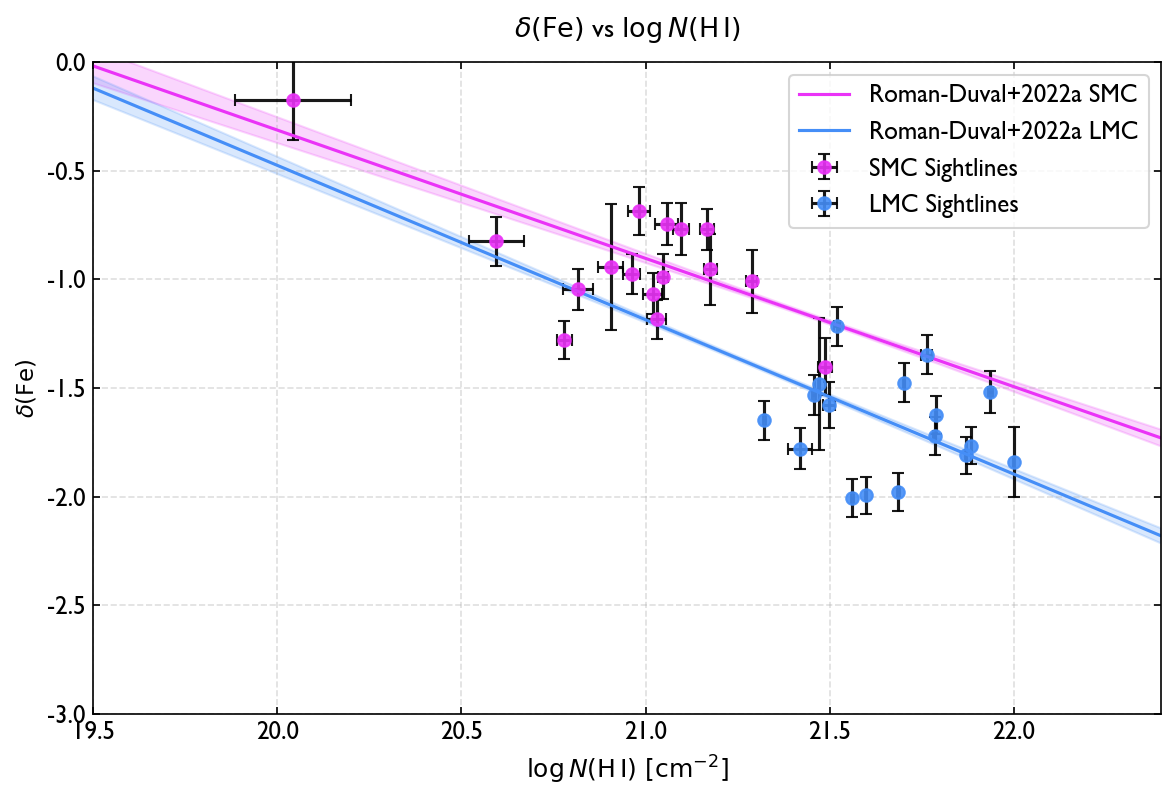

In [42]:
import io
import re
import matplotlib.pyplot as plt
import pandas as pd

# 1. Raw LaTeX Table Data
latex_data = """
A1 & Cl* NGC 346 ELS 22 & $21.176 \pm 0.017$ & $15.567 \pm 0.013$ & $15.114 \pm 0.138$ & $6.390 \pm 0.022$ & $5.937 \pm 0.139$ \\
A2 & Cl* NGC 346 ELS 50 & $20.816 \pm 0.040$ & $15.403 \pm 0.011$ & $14.662 \pm 0.008$ & $6.585 \pm 0.042$ & $5.844 \pm 0.041$ \\
A3 & Cl* NGC 346 ELS 51 & $20.905 \pm 0.033$ & $15.482 \pm 0.010$ & $14.853 \pm 0.275$ & $6.576 \pm 0.035$ & $5.947 \pm 0.277$ \\
A4 & Cl* NGC 346 ELS 7 & $21.096 \pm 0.022$ & $15.602 \pm 0.018$ & $15.218 \pm 0.081$ & $6.505 \pm 0.029$ & $6.121 \pm 0.084$ \\
A5 & Cl* NGC 346 MPG 782 & $20.043 \pm 0.157$ & $15.366 \pm 0.008$ & $14.767 \pm 0.041$ & $7.315 \pm 0.158$ & $6.716 \pm 0.163$ \\
A6 & Cl* NGC 346 NMC 17 & $21.288 \pm 0.016$ & $15.791 \pm 0.035$ & $15.170 \pm 0.116$ & $6.502 \pm 0.039$ & $5.881 \pm 0.117$ \\
A7 & Cl* NGC 346 NMC 28 & $21.030 \pm 0.026$ & $15.567 \pm 0.021$ & $14.737 \pm 0.007$ & $6.536 \pm 0.034$ & $5.706 \pm 0.027$ \\
A8 & Cl* NGC 346 SSN 25 & $21.487 \pm 0.019$ & $15.686 \pm 0.027$ & $14.976 \pm 0.099$ & $6.199 \pm 0.033$ & $5.489 \pm 0.101$ \\
A9 & Cl* NGC 346 SSN 7 & $20.962 \pm 0.024$ & $15.511 \pm 0.010$ & $14.876 \pm 0.023$ & $6.548 \pm 0.027$ & $5.913 \pm 0.034$ \\
A10 & Cl* NGC 346 W 3 & $21.048 \pm 0.013$ & $15.512 \pm 0.008$ & $14.952 \pm 0.059$ & $6.463 \pm 0.016$ & $5.903 \pm 0.061$ \\
A11 & Cl* NGC 346 W 4 & $21.019 \pm 0.026$ & $15.624 \pm 0.020$ & $14.844 \pm 0.027$ & $6.604 \pm 0.033$ & $5.824 \pm 0.038$ \\
A12 & HD 5980 & $21.057 \pm 0.031$ & $15.478 \pm 0.004$ & $14.918 \pm 0.026$ & $6.704 \pm 0.035$ & $6.144 \pm 0.043$ \\
A13 & SK 80 & $20.983 \pm 0.030$ & $15.529 \pm 0.012$ & $15.188 \pm 0.065$ & $6.545 \pm 0.032$ & $6.204 \pm 0.072$ \\
B1 & AzV 446 & $21.168 \pm 0.019$ & $15.613 \pm 0.010$ & $15.290 \pm 0.036$ & $6.444 \pm 0.022$ & $6.121 \pm 0.041$ \\
C1 & 2dFS 3694 & $20.779 \pm 0.020$ & $15.646 \pm 0.120$ & $14.392 \pm 0.011$ & $6.865 \pm 0.122$ & $5.611 \pm 0.023$ \\
D1 & SK 183 & $20.595 \pm 0.074$ & $15.353 \pm 0.013$ & $14.662 \pm 0.013$ & $6.756 \pm 0.075$ & $6.065 \pm 0.075$ \\
"""


def parse_val_err(cell_text):
    """Extract float value and uncertainty from '$val \\pm err$' string."""
    match = re.search(r"([\d\.]+)\s*\\pm\s*([\d\.]+)", cell_text)
    if match:
        return float(match.group(1)), float(match.group(2))
    raise ValueError(f"Could not parse string: {cell_text}")


# 2. Extract Data
rows = []
for line in latex_data.strip().split("\n"):
    if not line:
        continue
    cols = [c.strip() for c in line.split("&")]

    target_id = cols[0]
    target_name = cols[1]

    # Column 3 (index 2): log N(HI)
    nhi_val, nhi_err = parse_val_err(cols[2])

    # Column 7 (index 6): 12 + log(Fe/H)
    feh_val, feh_err = parse_val_err(cols[6])

    # Calculate D(Fe) = 6.89 - (12 + log(Fe/H))
    dfe_val = feh_val - 6.89
    dfe_err = np.sqrt(feh_err ** 2 + 0.08 ** 2 + 0.03 ** 2) # Direct error propagation

    rows.append({
        "ID": target_id,
        "Name": target_name,
        "NHI": nhi_val,
        "NHI_err": nhi_err,
        "DFe": dfe_val,
        "DFe_err": dfe_err,
    })

df = pd.DataFrame(rows)

# 3. Create Scatter Plot with Error Bars
fig, ax = plt.subplots(figsize=(8, 5.5), dpi=150)

ax.errorbar(
    df["NHI"],
    df["DFe"],
    xerr=df["NHI_err"],
    yerr=df["DFe_err"],
    fmt="o",
    color="#EA33F7",
    ecolor="black",
    capsize=3,
    capthick=1,
    markersize=6,
    alpha=0.9,
    label="SMC Sightlines",
)

latex_data = """
E1 & BAT99 113 & $21.785 \pm 0.003$ & $>15.851$ & $15.383 \pm 0.017$ & $>6.066$ & $5.598 \pm 0.017$ \\
E2 & BAT99 114 & $21.871 \pm 0.002$ & $>15.921$ & $15.381 \pm 0.016$ & $>6.050$ & $5.510 \pm 0.016$ \\
E3 & Brey 77 & $21.764 \pm 0.015$ & $>16.685$ & $15.737 \pm 0.025$ & $>6.921$ & $5.973 \pm 0.029$ \\
E4 & Cl* NGC 2070 MEL 25 & $21.788 \pm 0.003$ & $>15.944$ & $15.485 \pm 0.016$ & $>6.156$ & $5.697 \pm 0.016$ \\
E5 & Cl* NGC 2070 MEL 47 & $22.000 \pm 0.001$ & $>16.109$ & $15.479 \pm 0.135$ & $>6.109$ & $5.479 \pm 0.135$ \\
E6 & Cl* NGC 2070 MEL 55 & $21.702 \pm 0.004$ & $>15.998$ & $15.548 \pm 0.023$ & $>6.295$ & $5.845 \pm 0.023$ \\
E7 & Cl* NGC 2070 MH 57 & $21.885 \pm 0.002$ & $>16.127$ & $15.440 \pm 0.010$ & $>6.242$ & $5.555 \pm 0.010$ \\
E8 & RMC 140 & $21.936 \pm 0.007$ & $>16.292$ & $15.738 \pm 0.044$ & $>6.356$ & $5.802 \pm 0.045$ \\
F1 & BI 42 & $21.457 \pm 0.006$ & $>15.694$ & $15.245 \pm 0.037$ & $>6.237$ & $5.788 \pm 0.038$ \\
F2 & BRRG 75 & $21.520 \pm 0.007$ & $>15.994$ & $15.624 \pm 0.031$ & $>6.474$ & $6.104 \pm 0.032$ \\
F3 & PGMW 3053 & $21.323 \pm 0.004$ & $>15.605$ & $14.994 \pm 0.018$ & $>6.282$ & $5.671 \pm 0.019$ \\
F4 & PGMW 3058 & $21.598 \pm 0.003$ & $>15.622$ & $14.924 \pm 0.016$ & $>6.024$ & $5.326 \pm 0.016$ \\
F5 & PGMW 3100 & $21.687 \pm 0.003$ & $>15.599$ & $15.029 \pm 0.023$ & $>5.912$ & $5.342 \pm 0.023$ \\
F6 & PGMW 3120 & $21.498 \pm 0.016$ & $>15.828$ & $15.240 \pm 0.059$ & $>6.330$ & $5.742 \pm 0.061$ \\
F7 & PGMW 3168 & $21.472 \pm 0.003$ & $>15.682$ & $15.311 \pm 0.292$ & $>6.210$ & $5.839 \pm 0.292$ \\
F8 & PGMW 3204 & $21.419 \pm 0.032$ & $>15.695$ & $14.962 \pm 0.026$ & $>6.275$ & $5.542 \pm 0.041$ \\
F9 & [L72] LH 10-3061 & $21.561 \pm 0.004$ & $>15.746$ & $14.876 \pm 0.017$ & $>6.185$ & $5.315 \pm 0.017$ \\
"""


def parse_val_err(cell_text):
    """Extract float value and uncertainty from '$val \\pm err$' string."""
    match = re.search(r"([\d\.]+)\s*\\pm\s*([\d\.]+)", cell_text)
    if match:
        return float(match.group(1)), float(match.group(2))
    raise ValueError(f"Could not parse string: {cell_text}")


# 2. Extract Data
rows = []
for line in latex_data.strip().split("\n"):
    if not line:
        continue
    cols = [c.strip() for c in line.split("&")]

    target_id = cols[0]
    target_name = cols[1]

    # Column 3 (index 2): log N(HI)
    nhi_val, nhi_err = parse_val_err(cols[2])

    # Column 7 (index 6): 12 + log(Fe/H)
    feh_val, feh_err = parse_val_err(cols[6])

    # Calculate D(Fe) = 6.89 - (12 + log(Fe/H))
    dfe_val = feh_val - 7.32
    dfe_err = np.sqrt(feh_err ** 2 + 0.08 ** 2 + 0.03 ** 2) # Direct error propagation

    rows.append({
        "ID": target_id,
        "Name": target_name,
        "NHI": nhi_val,
        "NHI_err": nhi_err,
        "DFe": dfe_val,
        "DFe_err": dfe_err,
    })

df = pd.DataFrame(rows)

ax.errorbar(
    df["NHI"],
    df["DFe"],
    xerr=df["NHI_err"],
    yerr=df["DFe_err"],
    fmt="o",
    color="#458EF7",
    ecolor="black",
    capsize=3,
    capthick=1,
    markersize=6,
    alpha=0.9,
    label="LMC Sightlines",
)

# Label points by Target ID

ax.set_xlabel(r"$\log N(\mathrm{H\,I})\ [\mathrm{cm}^{-2}]$", fontsize=12)
ax.set_ylabel(
    r"$\delta (\mathrm{Fe})$",
    fontsize=11,
)
ax.set_title(
    r"$\delta (\mathrm{Fe})$ vs $\log N(\mathrm{H\,I})$",
    fontsize=13,
    pad=12,
)

ax.grid(True, linestyle="--", alpha=0.4)
ax.tick_params(
    axis="both", which="both", direction="in", top=True, right=True
)

x_line = np.linspace(19, 22.4, 200)
y_line = -1.18 - 0.59 * (x_line - 21.469)

# Propagate theory uncertainties: sigma^2 = (0.01)^2 + [0.04 * (x - 21.469)]^2
y_err = np.sqrt(0.01**2 + (0.04 * (x_line - 21.469)) ** 2)

ax.plot(
    x_line,
    y_line,
    color="#EA33F7",
    linestyle="-",
    linewidth=1.5,
    label=r"Roman-Duval+2022a SMC",
)

ax.fill_between(
    x_line,
    y_line - y_err,
    y_line + y_err,
    color="#EA33F7",
    alpha=0.2,
)

x_line = np.linspace(19, 22.4, 200)
y_line = -1.39 - 0.71 * (x_line - 21.288)

# Propagate theory uncertainties: sigma^2 = (0.01)^2 + [0.04 * (x - 21.469)]^2
y_err = np.sqrt(0.01**2 + (0.03 * (x_line - 21.288)) ** 2)

ax.plot(
    x_line,
    y_line,
    color="#458EF7",
    linestyle="-",
    linewidth=1.5,
    label=r"Roman-Duval+2022a LMC",
)

ax.fill_between(
    x_line,
    y_line - y_err,
    y_line + y_err,
    color="#458EF7",
    alpha=0.2
)

plt.xlim(19.5, 22.4)
plt.ylim(-3, 0)

plt.legend()

plt.tight_layout()
plt.show()

# theory: D(Fe)=(-1.18+/-0.01)+(-0.59+/-0.04)(log(NHI)-21.469)

In [ ]:
# END